In [41]:
import pandas as pd
path1= "hepatitiss\hepatitis.data"
attributes= ['Class', 'AGE', 'SEX', 'STEROID', 'ANTIVIRALS', 'FATIGUE', 'MALAISE', 'ANOREXIA', 
             'LIVER BIG', 'LIVER FIRM', 'SPLEEN PALPABLE', 'SPIDERS', 'ASCITES', 'VARICES', 
             'BILIRUBIN', 'ALK PHOSPHATE', 'SGOT', 'ALBUMIN', 'PROTIME', 'HISTOLOGY']
data= pd.read_csv(path1, names= attributes)

In [42]:
data['Class'].value_counts()

2    123
1     32
Name: Class, dtype: int64

In [43]:
data['Class'].replace(2, 0, inplace= True)

In [44]:
print('the data dimensions are (rows, cols): ', data.shape)

the data dimensions are (rows, cols):  (155, 20)


In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Class            155 non-null    int64 
 1   AGE              155 non-null    int64 
 2   SEX              155 non-null    int64 
 3   STEROID          155 non-null    object
 4   ANTIVIRALS       155 non-null    int64 
 5   FATIGUE          155 non-null    object
 6   MALAISE          155 non-null    object
 7   ANOREXIA         155 non-null    object
 8   LIVER BIG        155 non-null    object
 9   LIVER FIRM       155 non-null    object
 10  SPLEEN PALPABLE  155 non-null    object
 11  SPIDERS          155 non-null    object
 12  ASCITES          155 non-null    object
 13  VARICES          155 non-null    object
 14  BILIRUBIN        155 non-null    object
 15  ALK PHOSPHATE    155 non-null    object
 16  SGOT             155 non-null    object
 17  ALBUMIN          155 non-null    ob

In [46]:
data.head(20)

,Class,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY
0,0,30,2,1,2,2,2,2,1,2,2,2,2,2,1.00,85,18,4.0,?,1
1,0,50,1,1,2,1,2,2,1,2,2,2,2,2,0.90,135,42,3.5,?,1
2,0,78,1,2,2,1,2,2,2,2,2,2,2,2,0.70,96,32,4.0,?,1
3,0,31,1,?,1,2,2,2,2,2,2,2,2,2,0.70,46,52,4.0,80,1
4,0,34,1,2,2,2,2,2,2,2,2,2,2,2,1.00,?,200,4.0,?,1
5,0,34,1,2,2,2,2,2,2,2,2,2,2,2,0.90,95,28,4.0,75,1
6,1,51,1,1,2,1,2,1,2,2,1,1,2,2,?,?,?,?,?,1
7,0,23,1,2,2,2,2,2,2,2,2,2,2,2,1.00,?,?,?,?,1
8,0,39,1,2,2,1,2,2,2,1,2,2,2,2,0.70,?,48,4.4,?,1
9,0,30,1,2,2,2,2,2,2,2,2,2,2,2,1.00,?,120,3.9,?,1


In [47]:
data.replace('?', pd.NA, inplace=True)

In [48]:
data.isnull().sum()

Class               0
AGE                 0
SEX                 0
STEROID             1
ANTIVIRALS          0
FATIGUE             1
MALAISE             1
ANOREXIA            1
LIVER BIG          10
LIVER FIRM         11
SPLEEN PALPABLE     5
SPIDERS             5
ASCITES             5
VARICES             5
BILIRUBIN           6
ALK PHOSPHATE      29
SGOT                4
ALBUMIN            16
PROTIME            67
HISTOLOGY           0
dtype: int64

In [49]:
data= data.apply(pd.to_numeric)

In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Class            155 non-null    int64  
 1   AGE              155 non-null    int64  
 2   SEX              155 non-null    int64  
 3   STEROID          154 non-null    float64
 4   ANTIVIRALS       155 non-null    int64  
 5   FATIGUE          154 non-null    float64
 6   MALAISE          154 non-null    float64
 7   ANOREXIA         154 non-null    float64
 8   LIVER BIG        145 non-null    float64
 9   LIVER FIRM       144 non-null    float64
 10  SPLEEN PALPABLE  150 non-null    float64
 11  SPIDERS          150 non-null    float64
 12  ASCITES          150 non-null    float64
 13  VARICES          150 non-null    float64
 14  BILIRUBIN        149 non-null    float64
 15  ALK PHOSPHATE    126 non-null    float64
 16  SGOT             151 non-null    float64
 17  ALBUMIN         

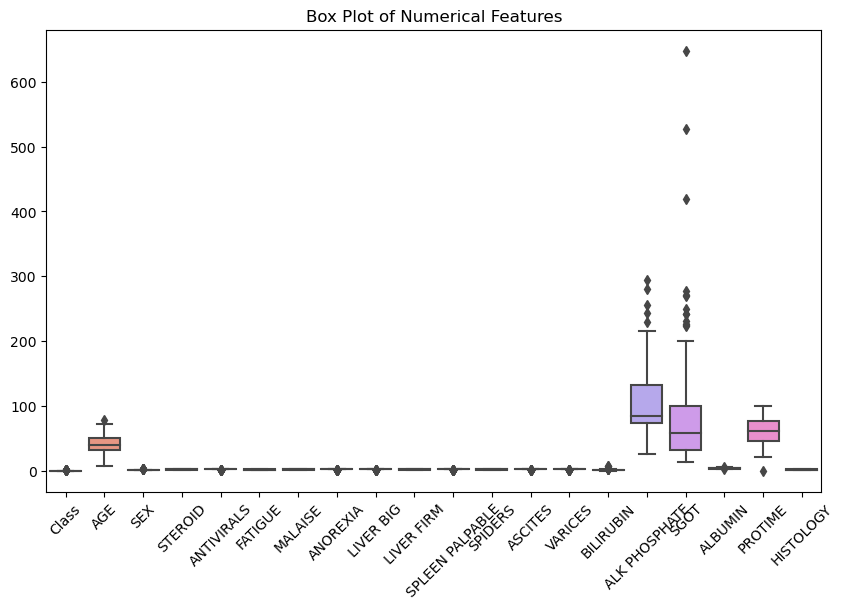

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(data=data)
plt.title('Box Plot of Numerical Features')
plt.xticks(rotation=45)
plt.show()

In [52]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

# Define a threshold for "high" number of missing values (e.g., more than 30% missing)
high_missing_threshold = 50

numeric_columns = ['AGE', 'BILIRUBIN', 'ALK PHOSPHATE', 'SGOT', 'ALBUMIN', 'PROTIME']

categorical_columns = ['SEX', 'STEROID', 'ANTIVIRALS', 'FATIGUE', 'MALAISE', 
                      'ANOREXIA', 'LIVER BIG', 'LIVER FIRM', 'SPLEEN PALPABLE', 
                      'SPIDERS', 'ASCITES', 'VARICES', 'HISTOLOGY']

# Identify columns with high missing values in numeric columns
high_missing_numeric_cols = [col for col in numeric_columns if data[col].isnull().sum() > high_missing_threshold]
low_missing_numeric_cols = [col for col in numeric_columns if col not in high_missing_numeric_cols]

# Step 1: Mean Impute for numeric columns with low missing values
mean_imputer = SimpleImputer(strategy='mean')
data[low_missing_numeric_cols] = mean_imputer.fit_transform(data[low_missing_numeric_cols])

# Step 2: MICE Imputer for numeric columns with high missing values
mice_imputer = IterativeImputer(
        estimator=RandomForestRegressor(n_estimators=100, max_depth=None, min_samples_split=2),
        random_state=42,
        max_iter=10
    )
data[high_missing_numeric_cols] = mice_imputer.fit_transform(data[high_missing_numeric_cols])

# Step 3: Mode Impute for categorical columns
mode_imputer = SimpleImputer(strategy='most_frequent')
data[categorical_columns] = mode_imputer.fit_transform(data[categorical_columns])

# Save the preprocessed dataset
data.to_csv('imputed_ucihep.csv', index=False)

In [53]:
data

,Class,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY
0,0,30.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,85.000000,18.0,4.0,61.852273,1.0
1,0,50.0,1.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,0.9,135.000000,42.0,3.5,61.852273,1.0
2,0,78.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,96.000000,32.0,4.0,61.852273,1.0
3,0,31.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,46.000000,52.0,4.0,80.000000,1.0
4,0,34.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,105.325397,200.0,4.0,61.852273,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,1,46.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,7.6,105.325397,242.0,3.3,50.000000,2.0
151,0,44.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,0.9,126.000000,142.0,4.3,61.852273,2.0
152,0,61.0,1.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,2.0,1.0,2.0,2.0,0.8,75.000000,20.0,4.1,61.852273,2.0
153,0,53.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,1.5,81.000000,19.0,4.1,48.000000,2.0


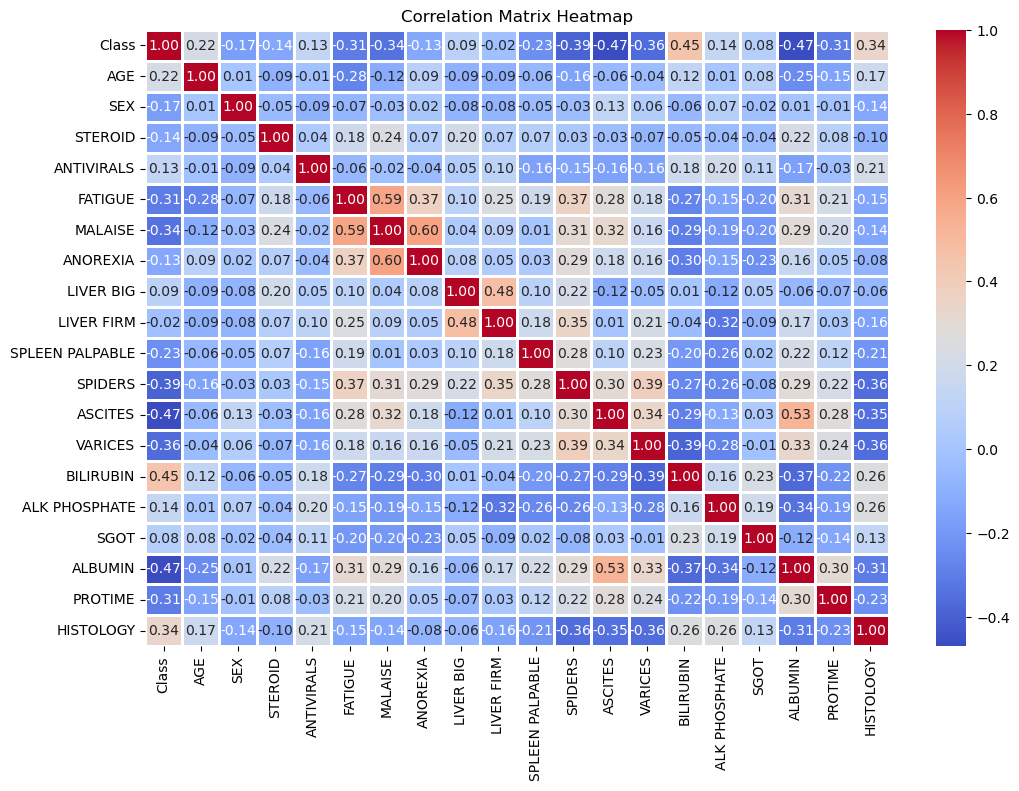

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix= data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=2)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [55]:
correlation_matrix = data.corr()
correlation_matrix

,Class,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY
Class,1.000000,0.219647,-0.173051,-0.137413,0.130196,-0.306049,-0.339530,-0.133638,0.093665,-0.020057,-0.234261,-0.389137,-0.469334,-0.362385,0.450470,0.141005,0.075579,-0.465827,-0.307238,0.337856
AGE,0.219647,1.000000,0.008126,-0.090466,-0.013100,-0.278701,-0.117876,0.088317,-0.089629,-0.092001,-0.061277,-0.156545,-0.055314,-0.039229,0.122884,0.008076,0.081052,-0.246169,-0.153312,0.170780
SEX,-0.173051,0.008126,1.000000,-0.048985,-0.089249,-0.070059,-0.030523,0.015886,-0.081830,-0.078642,-0.048478,-0.033192,0.130587,0.056792,-0.056218,0.073253,-0.017625,0.005459,-0.009125,-0.137450
STEROID,-0.137413,-0.090466,-0.048985,1.000000,0.043961,0.175451,0.240139,0.073644,0.201478,0.068376,0.074816,0.027290,-0.031046,-0.073548,-0.052804,-0.044223,-0.044154,0.216697,0.083434,-0.095367
ANTIVIRALS,0.130196,-0.013100,-0.089249,0.043961,1.000000,-0.061339,-0.016251,-0.042072,0.054746,0.099213,-0.164548,-0.147909,-0.164747,-0.155148,0.181179,0.197594,0.107876,-0.165443,-0.027317,0.209242
FATIGUE,-0.306049,-0.278701,-0.070059,0.175451,-0.061339,1.000000,0.589030,0.372957,0.099759,0.247505,0.186846,0.367948,0.281439,0.180511,-0.273577,-0.148708,-0.199808,0.311757,0.208021,-0.146579
MALAISE,-0.339530,-0.117876,-0.030523,0.240139,-0.016251,0.589030,1.000000,0.600545,0.041697,0.091832,0.006470,0.307173,0.320228,0.161422,-0.294889,-0.194920,-0.202801,0.290698,0.200760,-0.144667
ANOREXIA,-0.133638,0.088317,0.015886,0.073644,-0.042072,0.372957,0.600545,1.000000,0.079685,0.052781,0.032536,0.287366,0.184053,0.163378,-0.298034,-0.153634,-0.234824,0.155587,0.045235,-0.081623
LIVER BIG,0.093665,-0.089629,-0.081830,0.201478,0.054746,0.099759,0.041697,0.079685,1.000000,0.479779,0.095959,0.215566,-0.116465,-0.049453,0.008299,-0.124201,0.050390,-0.057149,-0.071565,-0.060262
LIVER FIRM,-0.020057,-0.092001,-0.078642,0.068376,0.099213,0.247505,0.091832,0.052781,0.479779,1.000000,0.180607,0.345553,0.010196,0.208047,-0.038876,-0.323892,-0.092868,0.174551,0.026348,-0.157118


In [56]:
target_corr = correlation_matrix['Class']
print('+ and < +0.2 \n', target_corr[(target_corr > 0) & (target_corr < 0.2)])
print('\n')
print('- and > -0.2 \n', target_corr[(target_corr < 0) & (target_corr > -0.2)])

+ and < +0.2 
 ANTIVIRALS       0.130196
LIVER BIG        0.093665
ALK PHOSPHATE    0.141005
SGOT             0.075579
Name: Class, dtype: float64


- and > -0.2 
 SEX          -0.173051
STEROID      -0.137413
ANOREXIA     -0.133638
LIVER FIRM   -0.020057
Name: Class, dtype: float64


In [57]:
# Identify features with weak positive and negative correlations
weak_positive_features = target_corr[(target_corr > 0) & (target_corr < 0.2)].index
weak_negative_features = target_corr[(target_corr < 0) & (target_corr > -0.2)].index

# Calculate pcf (Product of weakly positive correlated features)
data['PCF'] = data[weak_positive_features].prod(axis=1)

# Calculate ncf (Product of weakly negative correlated features)
data['NCF'] = data[weak_negative_features].prod(axis=1)

In [58]:
data

,Class,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,...,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY,PCF,NCF
0,0,30.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,...,2.0,2.0,1.0,85.000000,18.0,4.0,61.852273,1.0,3060.000000,8.0
1,0,50.0,1.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,...,2.0,2.0,0.9,135.000000,42.0,3.5,61.852273,1.0,11340.000000,4.0
2,0,78.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,...,2.0,2.0,0.7,96.000000,32.0,4.0,61.852273,1.0,12288.000000,8.0
3,0,31.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,0.7,46.000000,52.0,4.0,80.000000,1.0,4784.000000,8.0
4,0,34.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,1.0,105.325397,200.0,4.0,61.852273,1.0,84260.317460,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,1,46.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,2.0,...,1.0,1.0,7.6,105.325397,242.0,3.3,50.000000,2.0,101954.984127,4.0
151,0,44.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,1.0,...,2.0,2.0,0.9,126.000000,142.0,4.3,61.852273,2.0,71568.000000,4.0
152,0,61.0,1.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,...,2.0,2.0,0.8,75.000000,20.0,4.1,61.852273,2.0,3000.000000,2.0
153,0,53.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,...,2.0,1.0,1.5,81.000000,19.0,4.1,48.000000,2.0,6156.000000,8.0


In [59]:
correlation_matrix = data.corr()
correlation_matrix

,Class,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,...,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY,PCF,NCF
Class,1.000000,0.219647,-0.173051,-0.137413,0.130196,-0.306049,-0.339530,-0.133638,0.093665,-0.020057,...,-0.469334,-0.362385,0.450470,0.141005,0.075579,-0.465827,-0.307238,0.337856,0.064450,-0.234648
AGE,0.219647,1.000000,0.008126,-0.090466,-0.013100,-0.278701,-0.117876,0.088317,-0.089629,-0.092001,...,-0.055314,-0.039229,0.122884,0.008076,0.081052,-0.246169,-0.153312,0.170780,0.054017,-0.066063
SEX,-0.173051,0.008126,1.000000,-0.048985,-0.089249,-0.070059,-0.030523,0.015886,-0.081830,-0.078642,...,0.130587,0.056792,-0.056218,0.073253,-0.017625,0.005459,-0.009125,-0.137450,0.069441,0.348414
STEROID,-0.137413,-0.090466,-0.048985,1.000000,0.043961,0.175451,0.240139,0.073644,0.201478,0.068376,...,-0.031046,-0.073548,-0.052804,-0.044223,-0.044154,0.216697,0.083434,-0.095367,-0.020602,0.591753
ANTIVIRALS,0.130196,-0.013100,-0.089249,0.043961,1.000000,-0.061339,-0.016251,-0.042072,0.054746,0.099213,...,-0.164747,-0.155148,0.181179,0.197594,0.107876,-0.165443,-0.027317,0.209242,0.215719,0.010866
FATIGUE,-0.306049,-0.278701,-0.070059,0.175451,-0.061339,1.000000,0.589030,0.372957,0.099759,0.247505,...,0.281439,0.180511,-0.273577,-0.148708,-0.199808,0.311757,0.208021,-0.146579,-0.201983,0.355634
MALAISE,-0.339530,-0.117876,-0.030523,0.240139,-0.016251,0.589030,1.000000,0.600545,0.041697,0.091832,...,0.320228,0.161422,-0.294889,-0.194920,-0.202801,0.290698,0.200760,-0.144667,-0.245351,0.410772
ANOREXIA,-0.133638,0.088317,0.015886,0.073644,-0.042072,0.372957,0.600545,1.000000,0.079685,0.052781,...,0.184053,0.163378,-0.298034,-0.153634,-0.234824,0.155587,0.045235,-0.081623,-0.239931,0.427178
LIVER BIG,0.093665,-0.089629,-0.081830,0.201478,0.054746,0.099759,0.041697,0.079685,1.000000,0.479779,...,-0.116465,-0.049453,0.008299,-0.124201,0.050390,-0.057149,-0.071565,-0.060262,0.139085,0.336972
LIVER FIRM,-0.020057,-0.092001,-0.078642,0.068376,0.099213,0.247505,0.091832,0.052781,0.479779,1.000000,...,0.010196,0.208047,-0.038876,-0.323892,-0.092868,0.174551,0.026348,-0.157118,-0.112595,0.534074


In [60]:
# Calculate correlation matrix
target_corr = correlation_matrix['Class'] 

# Identify features to remove (those with correlation between -0.2 and +0.2 with the target)
features_to_remove = target_corr[(target_corr > -0.2) & (target_corr < 0.2)].index

# Drop identified features
data = data.drop(columns=features_to_remove)

In [61]:
data

,Class,AGE,FATIGUE,MALAISE,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALBUMIN,PROTIME,HISTOLOGY,NCF
0,0,30.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,4.0,61.852273,1.0,8.0
1,0,50.0,1.0,2.0,2.0,2.0,2.0,2.0,0.9,3.5,61.852273,1.0,4.0
2,0,78.0,1.0,2.0,2.0,2.0,2.0,2.0,0.7,4.0,61.852273,1.0,8.0
3,0,31.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,4.0,80.000000,1.0,8.0
4,0,34.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,4.0,61.852273,1.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,1,46.0,1.0,1.0,2.0,1.0,1.0,1.0,7.6,3.3,50.000000,2.0,4.0
151,0,44.0,1.0,2.0,2.0,2.0,2.0,2.0,0.9,4.3,61.852273,2.0,4.0
152,0,61.0,1.0,1.0,2.0,1.0,2.0,2.0,0.8,4.1,61.852273,2.0,2.0
153,0,53.0,1.0,2.0,1.0,1.0,2.0,1.0,1.5,4.1,48.000000,2.0,8.0


In [62]:
data.to_csv('imputed_fs_ucihep.csv', index= False)

In [63]:
data['Class'].value_counts()

0    123
1     32
Name: Class, dtype: int64

In [28]:
DF= data

In [29]:
X = DF.drop(columns=['Class'])
y = DF['Class']

In [32]:
import pandas as pd
from collections import Counter
from imblearn.over_sampling import RandomOverSampler, BorderlineSMOTE, SMOTE, ADASYN, SVMSMOTE
from imblearn.combine import SMOTEENN, SMOTETomek

def oversampling(X, y, oversample_method, method_name):
    print(f"Original class distribution for {method_name}:", Counter(y))
    X_resampled, y_resampled = oversample_method.fit_resample(X, y)
    print(f"Resampled class distribution for {method_name}:", Counter(y_resampled),'samples now', len(y_resampled))
    resampled_data = pd.DataFrame(data=X_resampled, columns=X.columns)
    resampled_data['Class'] = y_resampled
    resampled_data.to_csv(f'ucihep_{method_name}.csv', index=False)
    
    # Load the saved CSV into a variable
    globals()[f"data_{method_name}"] = pd.read_csv(f'ucihep_{method_name}.csv')

# Applying various oversampling methods
oversampling(X.copy(), y.copy(), RandomOverSampler(random_state=42), "ROS")
oversampling(X.copy(), y.copy(), BorderlineSMOTE(random_state=123), "Borderline_SMOTE")
oversampling(X.copy(), y.copy(), SMOTE(random_state=42), "SMOTE")
oversampling(X.copy(), y.copy(), ADASYN(random_state=42), "ADASYN")
oversampling(X.copy(), y.copy(), SVMSMOTE(random_state=42), "SVMSMOTE")
oversampling(X.copy(), y.copy(), SMOTEENN(random_state=42), "SMOTEENN")
oversampling(X.copy(), y.copy(), SMOTETomek(random_state=42), "SMOTETomek")

# Now the data will be loaded in variables like data_ROS, data_Borderline_SMOTE, etc.


Original class distribution for ROS: Counter({0: 123, 1: 32})
Resampled class distribution for ROS: Counter({0: 123, 1: 123}) samples now 246
Original class distribution for Borderline_SMOTE: Counter({0: 123, 1: 32})
Resampled class distribution for Borderline_SMOTE: Counter({0: 123, 1: 123}) samples now 246
Original class distribution for SMOTE: Counter({0: 123, 1: 32})
Resampled class distribution for SMOTE: Counter({0: 123, 1: 123}) samples now 246
Original class distribution for ADASYN: Counter({0: 123, 1: 32})
Resampled class distribution for ADASYN: Counter({1: 125, 0: 123}) samples now 248
Original class distribution for SVMSMOTE: Counter({0: 123, 1: 32})
Resampled class distribution for SVMSMOTE: Counter({0: 123, 1: 123}) samples now 246
Original class distribution for SMOTEENN: Counter({0: 123, 1: 32})
Resampled class distribution for SMOTEENN: Counter({1: 103, 0: 70}) samples now 173
Original class distribution for SMOTETomek: Counter({0: 123, 1: 32})
Resampled class distribu

In [27]:
data_ROS

,AGE,FATIGUE,MALAISE,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALBUMIN,PROTIME,HISTOLOGY,NCF,Class
0,30.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,4.000000,61.852273,1.0,8.0,0
1,50.0,1.0,2.0,2.0,2.0,2.0,2.0,0.9,3.500000,61.852273,1.0,4.0,0
2,78.0,1.0,2.0,2.0,2.0,2.0,2.0,0.7,4.000000,61.852273,1.0,8.0,0
3,31.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,4.000000,80.000000,1.0,8.0,0
4,34.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,4.000000,61.852273,1.0,8.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,48.0,1.0,1.0,2.0,1.0,1.0,1.0,4.8,2.700000,31.000000,2.0,2.0,1
242,33.0,1.0,1.0,2.0,2.0,1.0,2.0,0.7,3.000000,31.000000,2.0,4.0,1
243,37.0,1.0,2.0,2.0,1.0,2.0,2.0,0.6,4.200000,61.852273,1.0,8.0,1
244,42.0,1.0,1.0,2.0,1.0,2.0,2.0,0.5,3.800000,29.000000,2.0,4.0,1


In [33]:
data_SMOTE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AGE              246 non-null    float64
 1   FATIGUE          246 non-null    float64
 2   MALAISE          246 non-null    float64
 3   SPLEEN PALPABLE  246 non-null    float64
 4   SPIDERS          246 non-null    float64
 5   ASCITES          246 non-null    float64
 6   VARICES          246 non-null    float64
 7   BILIRUBIN        246 non-null    float64
 8   ALBUMIN          246 non-null    float64
 9   PROTIME          246 non-null    float64
 10  HISTOLOGY        246 non-null    float64
 11  NCF              246 non-null    float64
 12  Class            246 non-null    int64  
dtypes: float64(12), int64(1)
memory usage: 25.1 KB


In [34]:
data_SMOTE

,AGE,FATIGUE,MALAISE,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALBUMIN,PROTIME,HISTOLOGY,NCF,Class
0,30.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,4.000000,61.852273,1.000000,8.000000,0
1,50.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.900000,3.500000,61.852273,1.000000,4.000000,0
2,78.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.700000,4.000000,61.852273,1.000000,8.000000,0
3,31.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.700000,4.000000,80.000000,1.000000,8.000000,0
4,34.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,4.000000,61.852273,1.000000,8.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,44.607053,1.601176,2.000000,1.601176,1.000000,2.000000,1.000000,2.877414,3.880940,64.345785,2.000000,6.404702,1
242,49.898591,1.000000,1.816432,1.183568,1.000000,1.816432,2.000000,1.514250,3.557101,61.852273,1.183568,2.367136,1
243,40.185106,1.000000,1.000000,2.000000,1.201655,1.798345,2.000000,0.540331,3.638676,29.403310,2.000000,4.000000,1
244,44.547847,1.000000,1.000000,1.849282,1.000000,1.150718,1.849282,2.306937,2.535646,61.852273,2.000000,3.698565,1


In [37]:
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import RandomOverSampler, BorderlineSMOTE, SMOTE, ADASYN, SVMSMOTE
from imblearn.combine import SMOTEENN, SMOTETomek
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Define the oversampling methods
oversample_methods = {
    "ROS": RandomOverSampler(random_state=42),
    "Borderline_SMOTE": BorderlineSMOTE(random_state=123),
    "SMOTE": SMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42),
    "SVMSMOTE": SVMSMOTE(random_state=42),
    "SMOTEENN": SMOTEENN(random_state=42),
    "SMOTETomek": SMOTETomek(random_state=42)
}

# Function to perform Grid Search and evaluate the model
def perform_grid_search(model, param_grid, X_train, y_train):
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=10, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    print('Best Parameters:', grid_search.best_params_)
    print('Best Cross-Validation Accuracy:', grid_search.best_score_)
    return grid_search.best_estimator_

# Model parameter grids for hyperparameter tuning
lr_param_grid = {
    'max_iter': [100, 500, 1000, 10000], 
    'solver': ['lbfgs', 'liblinear', 'saga','newton-cholesky'],
    'penalty' : ['l1', 'l2', 'elasticnet', None],
    'random_state': [1, 7, 42]
}

knn_param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

svm_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly'],
    'random_state': [1, 7, 42]
}

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_features': [None, 'sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}

# AdaBoost parameter grid
adaboost_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1, 10]
}

# Gradient Boosting parameter grid
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1],
    'max_depth': [3, 5, 7]
}

# MLP parameter grid
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (150,)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'max_iter': [200, 500]
}

# XGBoost parameter grid
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

# Iterate over each oversampled dataset
for method_name, oversample_method in oversample_methods.items():
    print(f"\nRunning for {method_name} oversampling:")
    
    # Load the corresponding oversampled data
    data = pd.read_csv(f'ucihep_{method_name}.csv')
    X = data.drop(columns=['Class'])
    y = data['Class']
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Standardize the data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Logistic Regression
    print('\nLogistic Regression (LR)')
    lr = LogisticRegression(random_state=42)
    best_lr = perform_grid_search(lr, lr_param_grid, X_train_scaled, y_train)
    y_pred_lr = best_lr.predict(X_test_scaled)
    print('TEST accuracy:', accuracy_score(y_test, y_pred_lr))
    print(classification_report(y_test, y_pred_lr))

    # K-Nearest Neighbors
    print('\nK-Nearest Neighbors (KNN):')
    knn = KNeighborsClassifier()
    best_knn = perform_grid_search(knn, knn_param_grid, X_train_scaled, y_train)
    y_pred_knn = best_knn.predict(X_test_scaled)
    print('TEST accuracy:', accuracy_score(y_test, y_pred_knn))
    print(classification_report(y_test, y_pred_knn))

    # Support Vector Machine
    print('\nSupport Vector Machine (SVM):')
    svm = SVC(random_state=42)
    best_svm = perform_grid_search(svm, svm_param_grid, X_train_scaled, y_train)
    y_pred_svm = best_svm.predict(X_test_scaled)
    print('TEST accuracy:', accuracy_score(y_test, y_pred_svm))
    print(classification_report(y_test, y_pred_svm))

    # Random Forest
    print('\nRandom Forest (RF):')
    random_forest = RandomForestClassifier(random_state=1)
    grid_search_rf = GridSearchCV(estimator=random_forest, param_grid=rf_param_grid, cv=10, scoring='accuracy', n_jobs=1, verbose=0)
    grid_search_rf.fit(X_train_scaled, y_train)
    print('Best Parameters:', grid_search_rf.best_params_)
    print('Best Cross-Validation Accuracy:', grid_search_rf.best_score_)
    best_rf = grid_search_rf.best_estimator_
    y_pred_rf = best_rf.predict(X_test_scaled)
    print('Test Accuracy:', accuracy_score(y_test, y_pred_rf))
    print(classification_report(y_test, y_pred_rf))

    # AdaBoost
    print('\nAdaBoost Classifier (AdaBoost):')
    adaboost = AdaBoostClassifier(random_state=42)
    best_adaboost = perform_grid_search(adaboost, adaboost_param_grid, X_train_scaled, y_train)
    y_pred_adaboost = best_adaboost.predict(X_test_scaled)
    print('TEST accuracy:', accuracy_score(y_test, y_pred_adaboost))
    print(classification_report(y_test, y_pred_adaboost))

    # Gradient Boosting
    print('\nGradient Boosting Classifier (GradientBoosting):')
    gradient_boosting = GradientBoostingClassifier(random_state=42)
    best_gradient_boosting = perform_grid_search(gradient_boosting, gb_param_grid, X_train_scaled, y_train)
    y_pred_gradient_boosting = best_gradient_boosting.predict(X_test_scaled)
    print('TEST accuracy:', accuracy_score(y_test, y_pred_gradient_boosting))
    print(classification_report(y_test, y_pred_gradient_boosting))

    # MLP (Multilayer Perceptron)
    print('\nMLP Classifier (MLP):')
    mlp = MLPClassifier(random_state=42)
    best_mlp = perform_grid_search(mlp, mlp_param_grid, X_train_scaled, y_train)
    y_pred_mlp = best_mlp.predict(X_test_scaled)
    print('TEST accuracy:', accuracy_score(y_test, y_pred_mlp))
    print(classification_report(y_test, y_pred_mlp))

    # XGBoost
    print('\nXGBoost Classifier (XGB):')
    xgb = XGBClassifier(random_state=42)
    best_xgb = perform_grid_search(xgb, xgb_param_grid, X_train_scaled, y_train)
    y_pred_xgb = best_xgb.predict(X_test_scaled)
    print('TEST accuracy:', accuracy_score(y_test, y_pred_xgb))
    print(classification_report(y_test, y_pred_xgb))



Running for ROS oversampling:

Logistic Regression (LR)
Fitting 10 folds for each of 192 candidates, totalling 1920 fits


C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
840 fits failed out of a total of 1920.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1194, in fit
    solver

Best Parameters: {'max_iter': 100, 'penalty': 'l2', 'random_state': 1, 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.8473684210526315
TEST accuracy: 0.72
              precision    recall  f1-score   support

           0       0.60      0.90      0.72        20
           1       0.90      0.60      0.72        30

    accuracy                           0.72        50
   macro avg       0.75      0.75      0.72        50
weighted avg       0.78      0.72      0.72        50


K-Nearest Neighbors (KNN):
Fitting 10 folds for each of 10 candidates, totalling 100 fits
Best Parameters: {'n_neighbors': 1, 'weights': 'uniform'}
Best Cross-Validation Accuracy: 0.8981578947368419
TEST accuracy: 0.98
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       0.97      1.00      0.98        30

    accuracy                           0.98        50
   macro avg       0.98      0.97      0.98        50
weighted avg       0

C:\Users\sweth\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'bootstrap': False, 'criterion': 'gini', 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation Accuracy: 0.9289473684210525
Test Accuracy: 0.98
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       0.97      1.00      0.98        30

    accuracy                           0.98        50
   macro avg       0.98      0.97      0.98        50
weighted avg       0.98      0.98      0.98        50


AdaBoost Classifier (AdaBoost):
Fitting 10 folds for each of 12 candidates, totalling 120 fits


...

Best Parameters: {'C': 10, 'gamma': 1, 'kernel': 'rbf', 'random_state': 1}
Best Cross-Validation Accuracy: 0.9307017543859649
TEST accuracy: 0.8297872340425532
              precision    recall  f1-score   support

           0       0.76      0.90      0.83        21
           1       0.91      0.77      0.83        26

    accuracy                           0.83        47
   macro avg       0.83      0.84      0.83        47
weighted avg       0.84      0.83      0.83        47


Random Forest (RF):
Best Parameters: {'bootstrap': True, 'criterion': 'gini', 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.9257309941520468
Test Accuracy: 0.7872340425531915
              precision    recall  f1-score   support

           0       0.74      0.81      0.77        21
           1       0.83      0.77      0.80        26

    accuracy                           0.79        47
   macro avg       0.79      0.79      0.79        47
weighted

C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Best Parameters: {'learning_rate': 0.1, 'n_estimators': 50}
Best Cross-Validation Accuracy: 0.9096491228070176
TEST accuracy: 0.7659574468085106
              precision    recall  f1-score   support

           0       0.73      0.76      0.74        21
           1       0.80      0.77      0.78        26

    accuracy                           0.77        47
   macro avg       0.76      0.77      0.76        47
weighted avg       0.77      0.77      0.77        47


Gradient Boosting Classifier (GradientBoosting):
Fitting 10 folds for each of 36 candidates, totalling 360 fits
Best Parameters: {'learning_rate': 1, 'max_depth': 5, 'n_estimators': 50}
Best Cross-Validation Accuracy: 0.8883040935672515
TEST accuracy: 0.7446808510638298
              precision    recall  f1-score   support

           0       0.68      0.81      0.74        21
           1       0.82      0.69      0.75        26

    accuracy                           0.74        47
   macro avg       0.75      0.75     

C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (150,), 'max_iter': 500, 'solver': 'adam'}
Best Cross-Validation Accuracy: 0.9099415204678364
TEST accuracy: 0.851063829787234
              precision    recall  f1-score   support

           0       0.85      0.81      0.83        21
           1       0.85      0.88      0.87        26

    accuracy                           0.85        47
   macro avg       0.85      0.85      0.85        47
weighted avg       0.85      0.85      0.85        47


XGBoost Classifier (XGB):
Fitting 10 folds for each of 54 candidates, totalling 540 fits
Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best Cross-Validation Accuracy: 0.8883040935672515
TEST accuracy: 0.8297872340425532
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        21
           1       0.85      0.85      0.85        26

    accuracy                           0.83      

In [38]:
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import RandomOverSampler, BorderlineSMOTE, SMOTE, ADASYN, SVMSMOTE
from imblearn.combine import SMOTEENN, SMOTETomek
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Define the oversampling methods
oversample_methods = {
    "ROS": RandomOverSampler(random_state=42),
    "Borderline_SMOTE": BorderlineSMOTE(random_state=123),
    "SMOTE": SMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42),
    "SVMSMOTE": SVMSMOTE(random_state=42),
    "SMOTEENN": SMOTEENN(random_state=42),
    "SMOTETomek": SMOTETomek(random_state=42)
}

# Function to perform Grid Search and evaluate the model
def perform_grid_search(model, param_grid, X_train, y_train):
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    print('Best Parameters:', grid_search.best_params_)
    print('Best Cross-Validation Accuracy:', grid_search.best_score_)
    return grid_search.best_estimator_

# Model parameter grids for hyperparameter tuning
lr_param_grid = {
    'max_iter': [100, 500, 1000, 10000], 
    'solver': ['lbfgs', 'liblinear', 'saga','newton-cholesky'],
    'penalty' : ['l1', 'l2', 'elasticnet', None],
    'random_state': [1, 7, 42]
}

knn_param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

svm_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly'],
    'random_state': [1, 7, 42]
}

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_features': [None, 'sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}

# AdaBoost parameter grid
adaboost_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1, 10]
}

# Gradient Boosting parameter grid
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1],
    'max_depth': [3, 5, 7]
}

# MLP parameter grid
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (150,)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'max_iter': [200, 500]
}

# XGBoost parameter grid
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

# Iterate over each oversampled dataset
for method_name, oversample_method in oversample_methods.items():
    print(f"\nRunning for {method_name} oversampling:")
    
    # Load the corresponding oversampled data
    data = pd.read_csv(f'ucihep_{method_name}.csv')
    X = data.drop(columns=['Class'])
    y = data['Class']
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Standardize the data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Logistic Regression
    print('\nLogistic Regression (LR)')
    lr = LogisticRegression(random_state=42)
    best_lr = perform_grid_search(lr, lr_param_grid, X_train_scaled, y_train)
    y_pred_lr = best_lr.predict(X_test_scaled)
    print('TEST accuracy:', accuracy_score(y_test, y_pred_lr))
    print(classification_report(y_test, y_pred_lr))

    # K-Nearest Neighbors
    print('\nK-Nearest Neighbors (KNN):')
    knn = KNeighborsClassifier()
    best_knn = perform_grid_search(knn, knn_param_grid, X_train_scaled, y_train)
    y_pred_knn = best_knn.predict(X_test_scaled)
    print('TEST accuracy:', accuracy_score(y_test, y_pred_knn))
    print(classification_report(y_test, y_pred_knn))

    # Support Vector Machine
    print('\nSupport Vector Machine (SVM):')
    svm = SVC(random_state=42)
    best_svm = perform_grid_search(svm, svm_param_grid, X_train_scaled, y_train)
    y_pred_svm = best_svm.predict(X_test_scaled)
    print('TEST accuracy:', accuracy_score(y_test, y_pred_svm))
    print(classification_report(y_test, y_pred_svm))

    # Random Forest
    print('\nRandom Forest (RF):')
    random_forest = RandomForestClassifier(random_state=1)
    grid_search_rf = GridSearchCV(estimator=random_forest, param_grid=rf_param_grid, cv=10, scoring='accuracy', n_jobs=1, verbose=0)
    grid_search_rf.fit(X_train_scaled, y_train)
    print('Best Parameters:', grid_search_rf.best_params_)
    print('Best Cross-Validation Accuracy:', grid_search_rf.best_score_)
    best_rf = grid_search_rf.best_estimator_
    y_pred_rf = best_rf.predict(X_test_scaled)
    print('Test Accuracy:', accuracy_score(y_test, y_pred_rf))
    print(classification_report(y_test, y_pred_rf))

    # AdaBoost
    print('\nAdaBoost Classifier (AdaBoost):')
    adaboost = AdaBoostClassifier(random_state=42)
    best_adaboost = perform_grid_search(adaboost, adaboost_param_grid, X_train_scaled, y_train)
    y_pred_adaboost = best_adaboost.predict(X_test_scaled)
    print('TEST accuracy:', accuracy_score(y_test, y_pred_adaboost))
    print(classification_report(y_test, y_pred_adaboost))

    # Gradient Boosting
    print('\nGradient Boosting Classifier (GradientBoosting):')
    gradient_boosting = GradientBoostingClassifier(random_state=42)
    best_gradient_boosting = perform_grid_search(gradient_boosting, gb_param_grid, X_train_scaled, y_train)
    y_pred_gradient_boosting = best_gradient_boosting.predict(X_test_scaled)
    print('TEST accuracy:', accuracy_score(y_test, y_pred_gradient_boosting))
    print(classification_report(y_test, y_pred_gradient_boosting))

    # MLP (Multilayer Perceptron)
    print('\nMLP Classifier (MLP):')
    mlp = MLPClassifier(random_state=42)
    best_mlp = perform_grid_search(mlp, mlp_param_grid, X_train_scaled, y_train)
    y_pred_mlp = best_mlp.predict(X_test_scaled)
    print('TEST accuracy:', accuracy_score(y_test, y_pred_mlp))
    print(classification_report(y_test, y_pred_mlp))

    # XGBoost
    print('\nXGBoost Classifier (XGB):')
    xgb = XGBClassifier(random_state=42)
    best_xgb = perform_grid_search(xgb, xgb_param_grid, X_train_scaled, y_train)
    y_pred_xgb = best_xgb.predict(X_test_scaled)
    print('TEST accuracy:', accuracy_score(y_test, y_pred_xgb))
    print(classification_report(y_test, y_pred_xgb))



Running for ROS oversampling:

Logistic Regression (LR)
Fitting 5 folds for each of 192 candidates, totalling 960 fits


C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
420 fits failed out of a total of 960.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1194, in fit
    solver =

Best Parameters: {'max_iter': 100, 'penalty': 'l1', 'random_state': 1, 'solver': 'saga'}
Best Cross-Validation Accuracy: 0.8469230769230769
TEST accuracy: 0.72
              precision    recall  f1-score   support

           0       0.60      0.90      0.72        20
           1       0.90      0.60      0.72        30

    accuracy                           0.72        50
   macro avg       0.75      0.75      0.72        50
weighted avg       0.78      0.72      0.72        50


K-Nearest Neighbors (KNN):
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'n_neighbors': 9, 'weights': 'distance'}
Best Cross-Validation Accuracy: 0.8929487179487181
TEST accuracy: 0.98
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       0.97      1.00      0.98        30

    accuracy                           0.98        50
   macro avg       0.98      0.97      0.98        50
weighted avg       0.9

C:\Users\sweth\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'C': 1, 'gamma': 1, 'kernel': 'rbf', 'random_state': 1}
Best Cross-Validation Accuracy: 0.9234615384615384
TEST accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        30

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50


Random Forest (RF):
Best Parameters: {'bootstrap': False, 'criterion': 'gini', 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation Accuracy: 0.9289473684210525
Test Accuracy: 0.98
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       0.97      1.00      0.98        30

    accuracy                           0.98        50
   macro avg       0.98      0.97      0.98        50
weighted avg       0.98      0.98     

...

Best Parameters: {'max_iter': 100, 'penalty': None, 'random_state': 1, 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.8770981507823613
TEST accuracy: 0.8297872340425532
              precision    recall  f1-score   support

           0       0.84      0.76      0.80        21
           1       0.82      0.88      0.85        26

    accuracy                           0.83        47
   macro avg       0.83      0.82      0.83        47
weighted avg       0.83      0.83      0.83        47


K-Nearest Neighbors (KNN):
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'n_neighbors': 1, 'weights': 'uniform'}
Best Cross-Validation Accuracy: 0.8933143669985777
TEST accuracy: 0.851063829787234
              precision    recall  f1-score   support

           0       0.85      0.81      0.83        21
           1       0.85      0.88      0.87        26

    accuracy                           0.85        47
   macro avg       0.85      0.85      0.85      

C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Best Parameters: {'learning_rate': 0.1, 'n_estimators': 50}
Best Cross-Validation Accuracy: 0.9089615931721194
TEST accuracy: 0.7659574468085106
              precision    recall  f1-score   support

           0       0.73      0.76      0.74        21
           1       0.80      0.77      0.78        26

    accuracy                           0.77        47
   macro avg       0.76      0.77      0.76        47
weighted avg       0.77      0.77      0.77        47


Gradient Boosting Classifier (GradientBoosting):
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'learning_rate': 1, 'max_depth': 3, 'n_estimators': 50}
Best Cross-Validation Accuracy: 0.887908961593172
TEST accuracy: 0.8085106382978723
              precision    recall  f1-score   support

           0       0.80      0.76      0.78        21
           1       0.81      0.85      0.83        26

    accuracy                           0.81        47
   macro avg       0.81      0.80      0

C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (100,), 'max_iter': 500, 'solver': 'adam'}
Best Cross-Validation Accuracy: 0.9145092460881935
TEST accuracy: 0.851063829787234
              precision    recall  f1-score   support

           0       0.85      0.81      0.83        21
           1       0.85      0.88      0.87        26

    accuracy                           0.85        47
   macro avg       0.85      0.85      0.85        47
weighted avg       0.85      0.85      0.85        47


XGBoost Classifier (XGB):
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Best Cross-Validation Accuracy: 0.8879089615931722
TEST accuracy: 0.8297872340425532
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        21
           1       0.85      0.85      0.85        26

    accuracy                           0.83        4

C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\swe

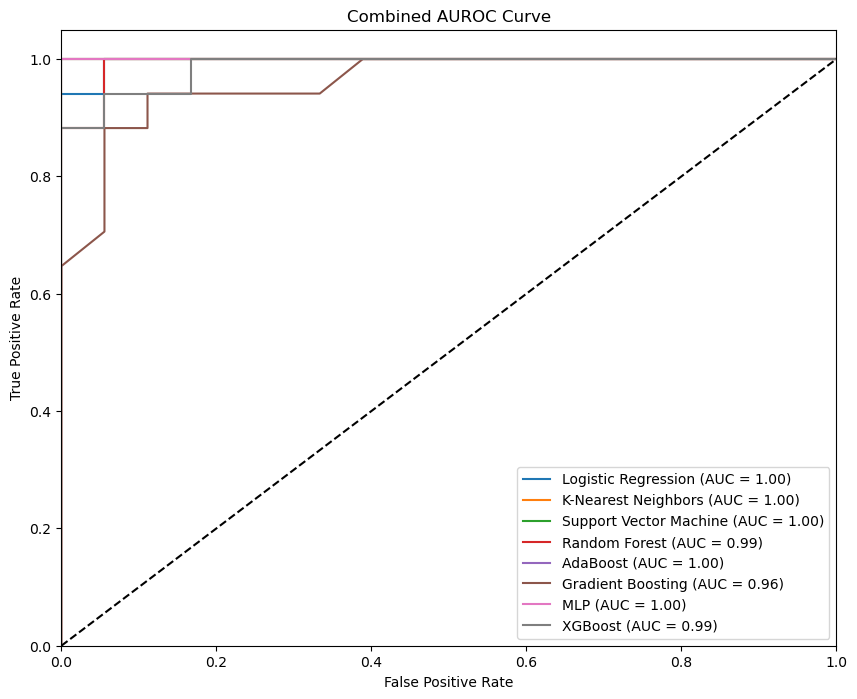

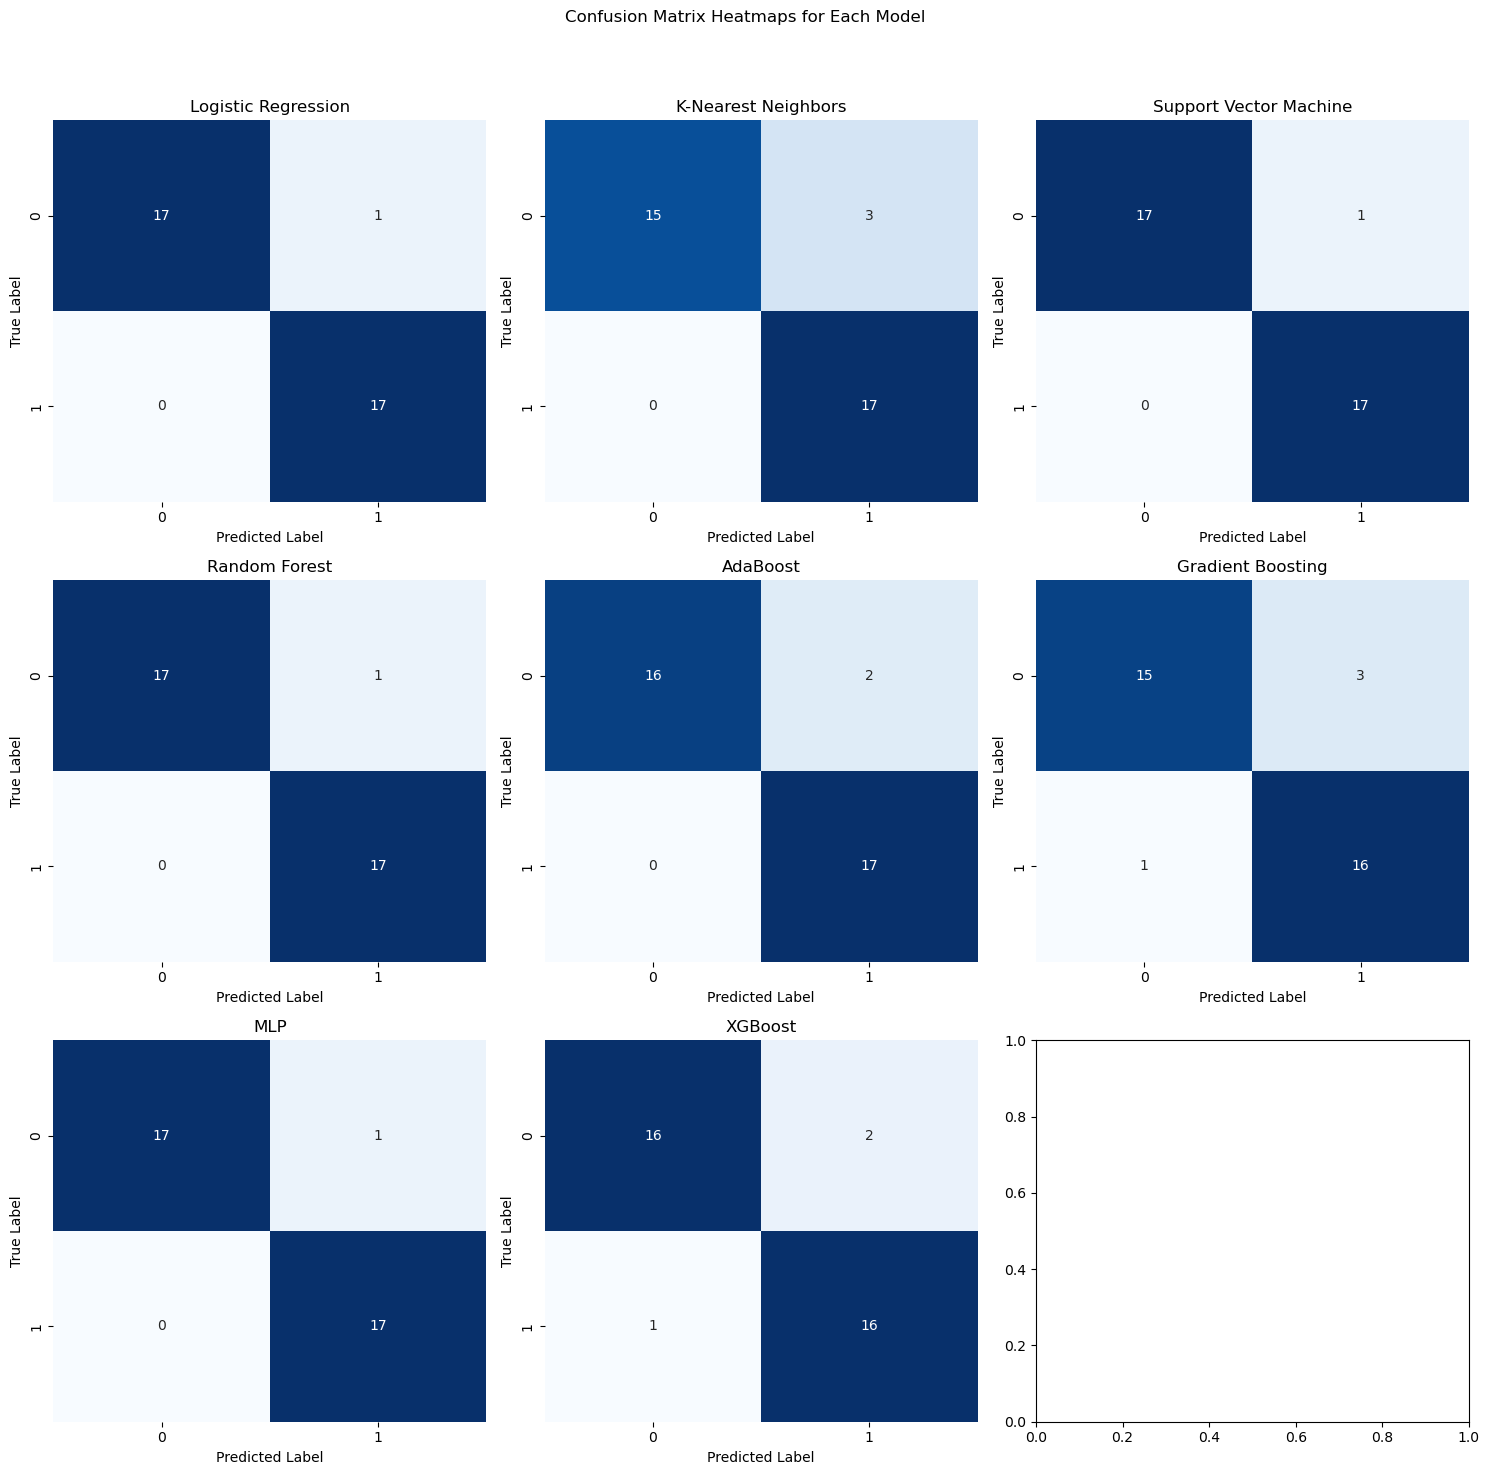


Summary Table:
                    Model  Accuracy  CV Accuracy  Sensitivity  Specificity  \
0     Logistic Regression  0.971429     0.963492     1.000000     0.944444   
1     K-Nearest Neighbors  0.914286     0.934392     1.000000     0.833333   
2  Support Vector Machine  0.971429     0.970635     1.000000     0.944444   
3           Random Forest  0.971429     0.956878     1.000000     0.944444   
4                AdaBoost  0.942857     0.935450     1.000000     0.888889   
5       Gradient Boosting  0.885714     0.941534     0.941176     0.833333   
6                     MLP  0.971429     0.956085     1.000000     0.944444   
7                 XGBoost  0.914286     0.971164     0.941176     0.888889   

   Precision  F-measure  
0   0.944444   0.971429  
1   0.850000   0.918919  
2   0.944444   0.971429  
3   0.944444   0.971429  
4   0.894737   0.944444  
5   0.842105   0.888889  
6   0.944444   0.971429  
7   0.888889   0.914286  


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, auc, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv('ucihep_SMOTEENN.csv')
X = data.drop(columns=['Class'])
y = data['Class']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models to evaluate
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(random_state=42, probability=True),
    "Random Forest": RandomForestClassifier(random_state=1),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "MLP": MLPClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

# Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize the table for storing metrics
metrics_table = []

# Plot AUROC Curve
plt.figure(figsize=(10, 8))
for name, model in models.items():
    # Train model
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test_scaled)
    
    # Metrics: Accuracy, Sensitivity, Specificity, Precision, F-measure
    accuracy = accuracy_score(y_test, y_pred)
    cv_accuracy = cross_val_score(model, X_train_scaled, y_train, cv=skf).mean()
    precision = precision_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1]) if (cm[0, 0] + cm[0, 1]) > 0 else 0
    f_measure = f1_score(y_test, y_pred)
    
    # Store metrics
    metrics_table.append({
        "Model": name,
        "Accuracy": accuracy,
        "CV Accuracy": cv_accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "F-measure": f_measure
    })
    
    # ROC and AUROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot settings for AUROC
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Combined AUROC Curve')
plt.legend(loc='lower right')
plt.show()

# Confusion Matrix Heatmaps
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('Confusion Matrix Heatmaps for Each Model')
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    # Predict again for confusion matrix visualization
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[idx])
    axes[idx].set_title(f"{name}")
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit suptitle
plt.show()

# Display the summarized metrics table
metrics_df = pd.DataFrame(metrics_table)
print("\nSummary Table:")
print(metrics_df)


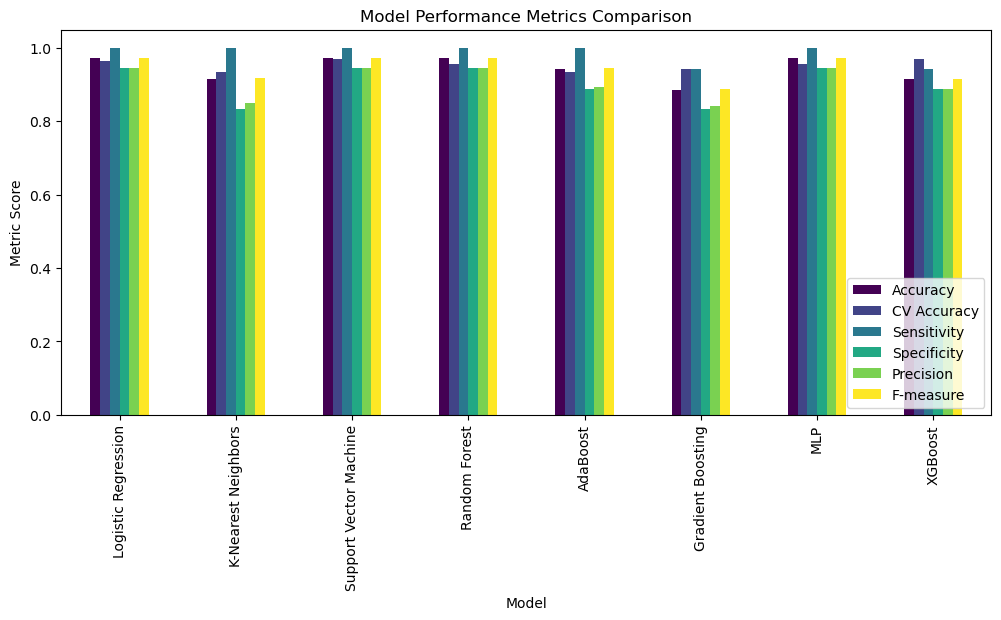

In [3]:
import pandas as pd

metrics_df = pd.DataFrame(metrics_table).set_index("Model")
metrics_df.plot(kind='bar', figsize=(12, 5), colormap='viridis')
plt.title('Model Performance Metrics Comparison')
plt.xlabel('Model')
plt.ylabel('Metric Score')
plt.legend(loc='lower right')
plt.show()
